<a href="https://colab.research.google.com/github/GunesCansu/Projet-Assurance/blob/main/notebook/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://www.data.gouv.fr/api/1/datasets/r/9b8cd622-36db-40ce-95e6-101d0aaf671c -O data.csv

--2026-06-10 11:50:20--  https://www.data.gouv.fr/api/1/datasets/r/9b8cd622-36db-40ce-95e6-101d0aaf671c
Resolving www.data.gouv.fr (www.data.gouv.fr)... 37.59.183.73, 37.59.183.91
Connecting to www.data.gouv.fr (www.data.gouv.fr)|37.59.183.73|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/4161_couverture-des-risques-sociaux-a-partir-des-donnees-acpr/exports/csv?use_labels=true [following]
--2026-06-10 11:50:20--  https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/4161_couverture-des-risques-sociaux-a-partir-des-donnees-acpr/exports/csv?use_labels=true
Resolving data.drees.solidarites-sante.gouv.fr (data.drees.solidarites-sante.gouv.fr)... 109.232.232.161, 5.104.97.33
Connecting to data.drees.solidarites-sante.gouv.fr (data.drees.solidarites-sante.gouv.fr)|109.232.232.161|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspe

In [2]:
import pandas as pd
df  = pd.read_csv('/content/data.csv',sep=';')
df.head()

,﻿Année,Type d'organismes complémentaires,Type de contrats,Montant,Cotisations/prestations,Code risque,Niveau du risque,Risque niveau 1,Risque niveau 2,Risque niveau 3,Risque niveau 4,Risque niveau 5,Risque niveau 6,Définition du risque
0,2024,Ensemble,Ensemble,26.95,Cotisations,1.2.0.0.0.0,2,1. Risques sociaux,1.2. Prévoyance,1.2.0. Prévoyance,1.2.0.0. Prévoyance,1.2.0.0.0. Prévoyance,1.2.0.0.0.0 Prévoyance,"Risques « Autres dommages corporels », « Décès..."
1,2024,Ensemble,Ensemble,8.88,Cotisations,1.2.2.1.0.0,4,1. Risques sociaux,1.2. Prévoyance,1.2.2. Décès,1.2.2.1. Temporaire,1.2.2.1.0. Temporaire,1.2.2.1.0.0 Temporaire,Garanties temporaires décès - invalidité avec ...
2,2024,Ensemble,Ensemble,0.11,Cotisations,1.2.3.0.0.0,3,1. Risques sociaux,1.2. Prévoyance,1.2.3. Perte d'emploi,1.2.3.0. Perte d'emploi,1.2.3.0.0. Perte d'emploi,1.2.3.0.0.0 Perte d'emploi,Garanties perte d'emploi - hors contrats empru...
3,2024,Ensemble,Ensemble,0.03,Cotisations,1.2.4.0.0.0,3,1. Risques sociaux,1.2. Prévoyance,1.2.4. Famille,1.2.4.0. Famille,1.2.4.0.0. Famille,1.2.4.0.0.0 Famille,Garanties famille
4,2024,Ensemble,Ensemble,20.29,Cotisations,1.3.0.0.0.0,2,1. Risques sociaux,1.3. Retraite,1.3.0. Retraite,1.3.0.0. Retraite,1.3.0.0.0. Retraite,1.3.0.0.0.0 Retraite,"Retraite supplémentaire, préretraite, indemnit..."


Analyse des risques et de la rentabilité des organismes complémentaires

In [3]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6038 entries, 0 to 6037
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ﻿Année                             6038 non-null   int64  
 1   Type d'organismes complémentaires  6038 non-null   object 
 2   Type de contrats                   6038 non-null   object 
 3   Montant                            6038 non-null   float64
 4   Cotisations/prestations            6038 non-null   object 
 5   Code risque                        6038 non-null   object 
 6   Niveau du risque                   6038 non-null   int64  
 7   Risque niveau 1                    6038 non-null   object 
 8   Risque niveau 2                    6038 non-null   object 
 9   Risque niveau 3                    6038 non-null   object 
 10  Risque niveau 4                    6038 non-null   object 
 11  Risque niveau 5                    6038 non-null   objec

,﻿Année,Montant,Niveau du risque
count,6038.000000,6038.000000,6038.000000
mean,2020.572706,5.398917,3.411560
std,2.778547,24.465060,1.347903
min,2011.000000,-0.220000,0.000000
25%,2019.000000,0.000000,2.000000
50%,2021.000000,0.090000,4.000000
75%,2023.000000,1.810000,4.000000
max,2024.000000,316.530000,6.000000


In [4]:
#Nettoyage

df.columns = df.columns.str.strip()

In [5]:
df.columns

Index(['﻿Année', 'Type d'organismes complémentaires', 'Type de contrats',
       'Montant', 'Cotisations/prestations', 'Code risque', 'Niveau du risque',
       'Risque niveau 1', 'Risque niveau 2', 'Risque niveau 3',
       'Risque niveau 4', 'Risque niveau 5', 'Risque niveau 6',
       'Définition du risque'],
      dtype='object')

In [6]:
# Remplacer total 0

df["Risque niveau 1"] = df["Risque niveau 1"].replace(
    {"0. Total": "Total général"}
)

In [14]:
# Exclure des graphiques total 0

df_plot = df[df["Risque niveau 1"] != "0. Total"]

In [9]:
# Types d'organismes complémentaires

df["Type d'organismes complémentaires"].value_counts()

,count
Type d'organismes complémentaires,
Ensemble,1256
Mutuelles,1205
Entreprises d'assurance,1205
Institutions de prévoyance,1205
Organismes de retraite professionnelle supplémentaire,1167


In [10]:
# Types de contrats

df["Type de contrats"].value_counts()

,count
Type de contrats,
Ensemble,2468
Individuel,1785
Collectif,1785


In [11]:
#Cotisations vs prestations

df["Cotisations/prestations"].value_counts()

,count
Cotisations/prestations,
Cotisations,3022
Prestations,3016


In [12]:
# Hierarchie des risques

df["Risque niveau 1"].value_counts()

,count
Risque niveau 1,
1. Risques sociaux,5820
Total général,109
2. Hors risques sociaux,109


In [13]:
df.groupby("Risque niveau 1")["Montant"] \
  .sum() \
  .sort_values(ascending=False)

,Montant
Risque niveau 1,
1. Risques sociaux,14124.49
Total général,10809.67
2. Hors risques sociaux,7664.50


/tmp/ipykernel_2478/1013154785.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


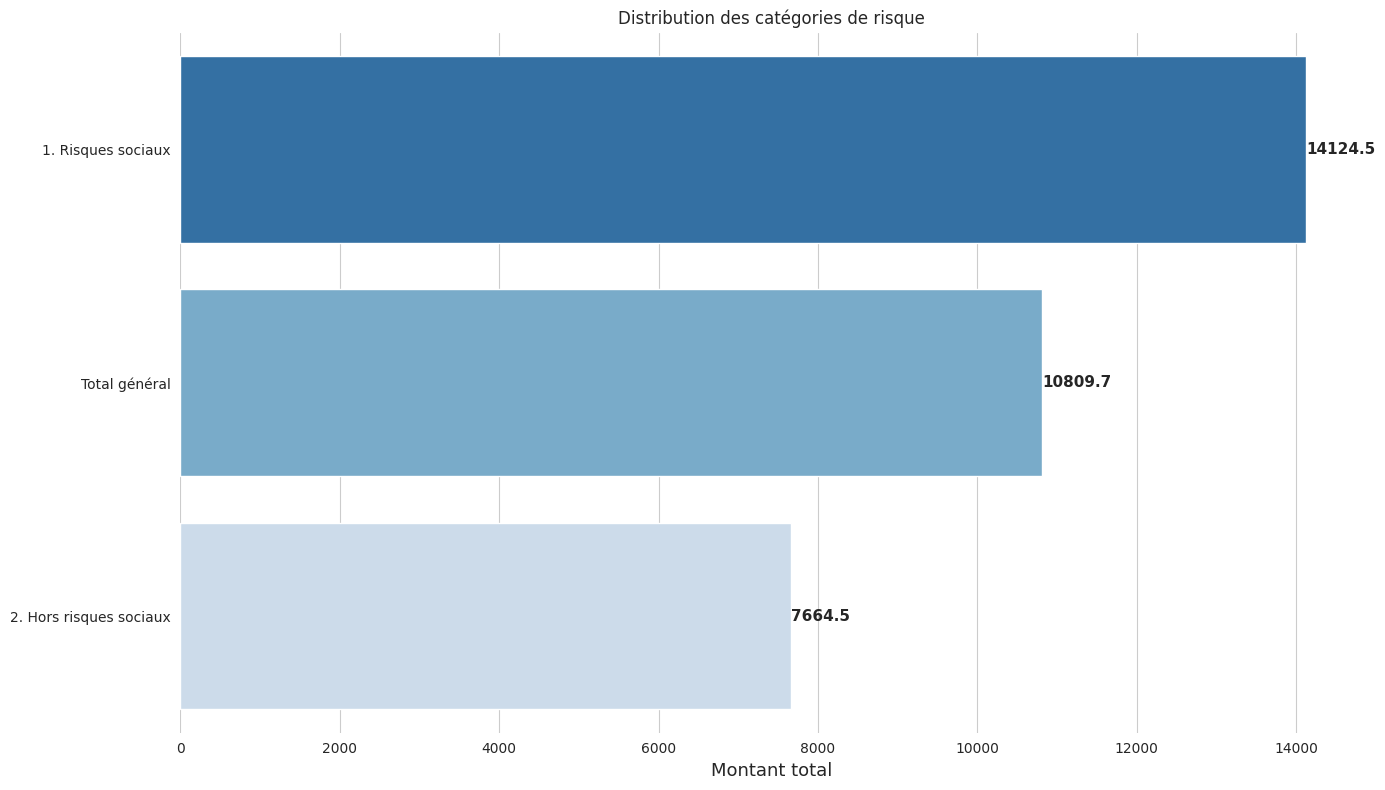

In [19]:
# Risques par montant total



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style général
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Agrégation des données
top_risques = (
    df.groupby("Risque niveau 1")["Montant"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Palette de couleurs
palette = sns.color_palette("Blues_r", len(top_risques))

# Barplot
ax = sns.barplot(
    data=top_risques,
    x="Montant",
    y="Risque niveau 1",
    palette=palette
)

# Ajouter les labels sur les barres
for i, value in enumerate(top_risques["Montant"]):
    ax.text(
        value + 1,
        i,
        f"{value:.1f}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Titres
    plt.title("Distribution des catégories de risque")
    fontsize=20,
    fontweight='bold',
    pad=20


plt.xlabel("Montant total", fontsize=13)
plt.ylabel("")

# Nettoyage visuel
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Analyse des principaux risques
L’analyse des montants par catégorie de risque révèle une forte concentration des flux financiers sur un nombre limité de segments.

Les risques liés à la prévoyance représentent une part significative des montants observés, suggérant une exposition importante des organismes complémentaires sur ces catégories.

La distribution asymétrique des montants indique également que certains risques jouent un rôle central dans la structure financière globale du secteur.

In [21]:
# Comparaison des cotisation et les prestations dans le temps

evolution = (
    df.groupby(
        ["Année", "Cotisations/prestations"]
    )["Montant"]
    .sum()
    .reset_index()
)

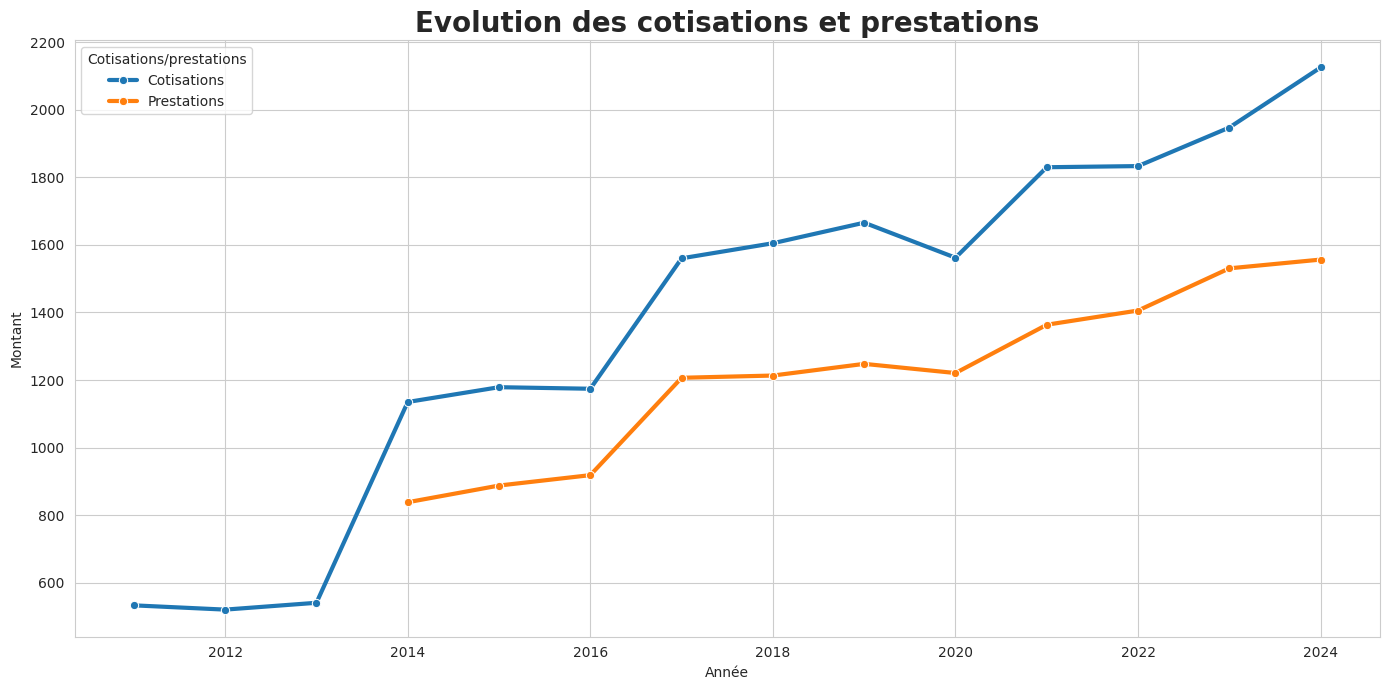

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

plt.figure(figsize=(14,7))

sns.lineplot(
    data=evolution,
    x="Année",
    y="Montant",
    hue="Cotisations/prestations",
    marker="o",
    linewidth=3
)

plt.title(
    "Evolution des cotisations et prestations",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Année")
plt.ylabel("Montant")

plt.tight_layout()
plt.show()

Les prestations connaissent une croissance plus rapide que les cotisations,
ce qui pourrait exercer une pression financière croissante sur les organismes complémentaires.

In [21]:
# Ajout regression lineaire

from sklearn.linear_model import LinearRegression
import numpy as np

In [22]:
X = df["Année"].values.reshape(-1, 1)
y = df["Prestations"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

KeyError: 'Année'

In [23]:
print(df.columns.tolist())

['\ufeffAnnée', "Type d'organismes complémentaires", 'Type de contrats', 'Montant', 'Cotisations/prestations', 'Code risque', 'Niveau du risque', 'Risque niveau 1', 'Risque niveau 2', 'Risque niveau 3', 'Risque niveau 4', 'Risque niveau 5', 'Risque niveau 6', 'Définition du risque']


In [24]:
df.columns = df.columns.str.replace('\ufeff', '', regex=False)
df.columns = df.columns.str.strip()

In [25]:
print(df.columns.tolist())

['Année', "Type d'organismes complémentaires", 'Type de contrats', 'Montant', 'Cotisations/prestations', 'Code risque', 'Niveau du risque', 'Risque niveau 1', 'Risque niveau 2', 'Risque niveau 3', 'Risque niveau 4', 'Risque niveau 5', 'Risque niveau 6', 'Définition du risque']


In [27]:
evolution = (
    df.groupby(["Année", "Cotisations/prestations"])["Montant"]
      .sum()
      .reset_index()
)

pivot = evolution.pivot(
    index="Année",
    columns="Cotisations/prestations",
    values="Montant"
).reset_index()

print(pivot.head())

Cotisations/prestations  Année  Cotisations  Prestations
0                         2011       532.87          NaN
1                         2012       520.26          NaN
2                         2013       540.49          NaN
3                         2014      1134.91       838.16
4                         2015      1178.69       887.56


In [29]:
# Suppression NaN

pivot_clean = pivot.dropna(subset=["Prestations"])


from sklearn.linear_model import LinearRegression

X = pivot_clean["Année"].values.reshape(-1, 1)
y = pivot_clean["Prestations"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

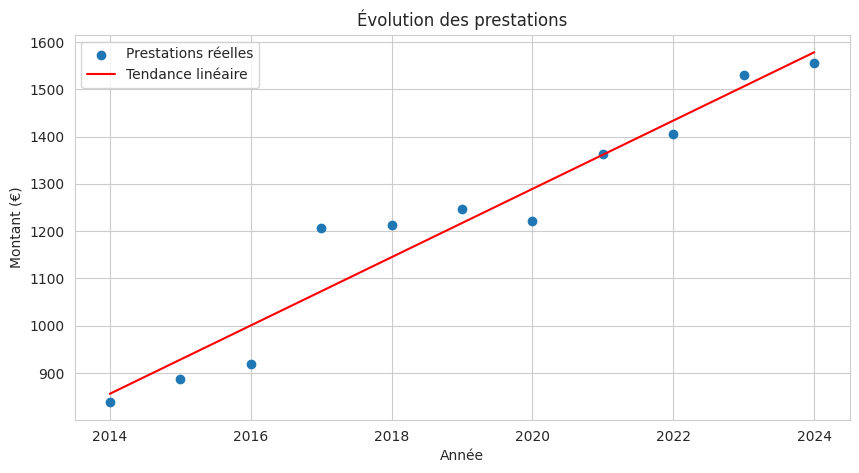

In [30]:
# Affichage du graphique

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    pivot_clean["Année"],
    pivot_clean["Prestations"],
    label="Prestations réelles"
)

plt.plot(
    pivot_clean["Année"],
    y_pred,
    color="red",
    label="Tendance linéaire"
)

plt.xlabel("Année")
plt.ylabel("Montant (€)")
plt.title("Évolution des prestations")
plt.legend()

plt.show()